# ErgTrainer recording investigation

Choose a recording above, then run the analysis cells from **Load and check** onward. After changing the dropdown, rerun those cells. The CSV files are read only; this notebook does not modify them.

In [23]:
from pathlib import Path

import ipywidgets as widgets
import pandas as pd
from IPython.display import display

# Matches SignalRecorder's default output location. Edit if you store recordings elsewhere.
recordings_directory = Path.home() / 'Documents' / 'ErgTrainer' / 'Recordings'
recordings_directory

WindowsPath('C:/Users/ferdi/Documents/ErgTrainer/Recordings')

In [24]:
def find_recordings(directory: Path) -> list[Path]:
    if not directory.is_dir():
        return []
    return sorted(directory.glob('*.csv'), key=lambda path: path.stat().st_mtime, reverse=True)

recordings = find_recordings(recordings_directory)
print(f'Found {len(recordings)} CSV file(s) in {recordings_directory}')

Found 2 CSV file(s) in C:\Users\ferdi\Documents\ErgTrainer\Recordings


In [25]:
file_dropdown = widgets.Dropdown(
    options=[(path.name, path) for path in recordings],
    description='Recording:',
    layout=widgets.Layout(width='650px'),
)
refresh_button = widgets.Button(description='Refresh file list')

def refresh_files(_):
    global recordings
    recordings = find_recordings(recordings_directory)
    file_dropdown.options = [(path.name, path) for path in recordings]

refresh_button.on_click(refresh_files)
display(widgets.HBox([file_dropdown, refresh_button]))

In [27]:
preview_output = widgets.Output()

def preview_recording(change=None):
    with preview_output:
        preview_output.clear_output()
        selected_file = file_dropdown.value
        if selected_file is None:
            print('No CSV files found. Check recordings_directory and click Refresh file list.')
            return
        preview = pd.read_csv(selected_file, keep_default_na=False)
        print(f'{selected_file.name}: {len(preview):,} row(s)')
        display(preview.head())

file_dropdown.observe(preview_recording, names='value')
display(preview_output)
preview_recording()


Output()

## Load and check

Each CSV row is one captured BLE characteristic value: a notification sent by the device, or a value returned by a poll (read). A value can contain several fields, and a new transmission does not guarantee a new underlying measurement. A poll often reads the value most recently sent by notification; the device can also send the same value again while nothing changes. Some heart-rate packets include more than one RR interval (beat-to-beat duration), so a packet is not necessarily one physiological sample or a batch of heart-rate samples.

The table counts transmissions by source and delivery method. Empty, odd-length, and non-hex payloads are counted before decoding.

In [28]:
import matplotlib.pyplot as plt

selected_file = file_dropdown.value
if selected_file is None:
    raise ValueError('Select a recording in the dropdown first.')

recording = pd.read_csv(selected_file, keep_default_na=False)
recording['timestamp'] = pd.to_datetime(recording['timestamp_utc'], utc=True, errors='coerce')
recording['payload'] = recording['raw_hex'].map(
    lambda value: bytes.fromhex(value) if isinstance(value, str)
    and len(value) % 2 == 0 and all(ch in '0123456789abcdefABCDEF' for ch in value)
    else None
)
recording = recording.sort_values('timestamp', kind='stable').reset_index(drop=True)
start = recording['timestamp'].min()
recording['elapsed_s'] = (recording['timestamp'] - start).dt.total_seconds()

print(f'{selected_file.name}: {len(recording):,} rows')
print(f'UTC: {start} to {recording["timestamp"].max()}')
print(f'Invalid timestamps: {recording["timestamp"].isna().sum()}')
print(f'Empty or invalid hex payloads: {recording["payload"].map(lambda p: p is None or len(p) == 0).sum()}')
display(recording.groupby(['source', 'delivery_method', 'characteristic_uuid'], dropna=False)
        .agg(packets=('raw_hex', 'size'),
             empty_payloads=('payload', lambda values: sum(p is None or len(p) == 0 for p in values)))
        .reset_index())


raw-signals-20261009-193718889.csv: 2,492 rows
UTC: 2026-10-09 17:37:19.096020300+00:00 to 2026-10-09 17:57:42.612832200+00:00
Invalid timestamps: 0
Empty or invalid hex payloads: 0


,source,delivery_method,characteristic_uuid,packets,empty_payloads
0,heart-rate-monitor,notification,00002a37-0000-1000-8000-00805f9b34fb,869,0
1,heart-rate-monitor,poll,00002a37-0000-1000-8000-00805f9b34fb,403,0
2,trainer,notification,00002a63-0000-1000-8000-00805f9b34fb,1220,0


### What can one HR packet contain?

The flags tell us whether RR intervals are included. The count below shows how many intervals are in each notification, including zero. This is the one place in these recordings where a packet may carry multiple beat-to-beat observations. The bpm field is still one current heart-rate estimate, not one bpm value per interval.

[Bluetooth SIG Heart Rate Service](https://www.bluetooth.com/wp-content/uploads/Files/Specification/HTML/HRS_v1.0/out/en/index-en.html) describes this variable-length RR field.

In [29]:
def rr_interval_count(payload):
    if not payload or len(payload) < 2:
        return None
    flags = payload[0]
    position = 1 + (2 if flags & 0x01 else 1) + (2 if flags & 0x08 else 0)
    if len(payload) < position:
        return None
    return (len(payload) - position) // 2 if flags & 0x10 else 0

hr_notifications_raw = recording[
    (recording['characteristic_uuid'].str.lower() == '00002a37-0000-1000-8000-00805f9b34fb')
    & (recording['delivery_method'] == 'notification')
]
display(hr_notifications_raw['payload'].map(rr_interval_count)
        .value_counts(dropna=False).sort_index().rename_axis('RR intervals in packet')
        .to_frame('notifications'))


,notifications
RR intervals in packet,
0,121
1,685
2,62
3,1


## Packet timing

An interval is the time between two captured rows from the same source and delivery method. It measures communication timing, not the time between heartbeats or pedal turns. A long interval may reflect a pause or missed data.

In [30]:
timing = recording.dropna(subset=['timestamp']).copy()
timing['interval_s'] = timing.groupby(['source', 'delivery_method'])['timestamp'].diff().dt.total_seconds()
display(timing.groupby(['source', 'delivery_method'])['interval_s']
        .agg(['count', 'median', 'min', 'max']).round(2))


count  median   min   max
source             delivery_method                           
heart-rate-monitor notification       868    0.72  0.00  2.64
                   poll               402    1.44  1.44  3.12
trainer            notification      1219    0.96  0.48  1.44

## Fields we can identify from the characteristic

Heart Rate Measurement (2A37) contains an 8- or 16-bit heart-rate value and can also contain RR intervals. Cycling Power Measurement (2A63) contains signed instantaneous power in bytes 2-3. These are fields defined by the Bluetooth characteristics. A value can be repeated across transmissions; the notebook does not count each row as a distinct heartbeat or pedal revolution.

In [31]:
HR_UUID = '00002a37-0000-1000-8000-00805f9b34fb'
POWER_UUID = '00002a63-0000-1000-8000-00805f9b34fb'

def decode_heart_rate(payload):
    if not payload:
        return None
    width = 2 if payload[0] & 1 else 1
    return int.from_bytes(payload[1:1 + width], 'little') if len(payload) >= 1 + width else None

def decode_power(payload):
    return int.from_bytes(payload[2:4], 'little', signed=True) if payload and len(payload) >= 4 else None

heart = recording[recording['characteristic_uuid'].str.lower() == HR_UUID].copy()
trainer = recording[recording['characteristic_uuid'].str.lower() == POWER_UUID].copy()
heart['heart_rate_bpm'] = heart['payload'].map(decode_heart_rate)
trainer['power_w'] = trainer['payload'].map(decode_power)
trainer['flags'] = trainer['payload'].map(
    lambda p: f'0x{int.from_bytes(p[:2], "little"):04X}' if p and len(p) >= 2 else None
)
display(heart.groupby('delivery_method')['heart_rate_bpm'].agg(['count', 'min', 'median', 'max']))
display(trainer.groupby('flags')['power_w'].agg(['count', 'min', 'median', 'max']))


,count,min,median,max
delivery_method,,,,
notification,869,57,74.0,124
poll,403,57,74.0,123


,count,min,median,max
flags,,,,
0x0003,1220,0,0.0,276


## Documented cadence in new recordings

The app now subscribes to CSC Measurement (2A5B) when the trainer offers it. New CSVs will show `service_uuid` ending in `1816` and `characteristic_uuid` ending in `2a5b`. The older recordings have no such rows.

A CSC packet can include cumulative crank revolutions and a timestamp for the last crank event. Cadence is calculated from the **change between successive events**, with event time in 1/1024-second units. An unchanged counter means no new event was observed in that packet; it is shown as missing rather than inventing a new RPM. The counters wrap around, so differences use their specified widths. This calculation uses the [Bluetooth CSC specification](https://www.bluetooth.com/wp-content/uploads/Files/Specification/HTML/CSCS_v1.0/out/en/index-en.html).

In [ ]:
CSC_UUID = '00002a5b-0000-1000-8000-00805f9b34fb'

def decode_csc(payload):
    if not payload:
        return (None, None, None)
    flags = payload[0]
    offset = 1
    if flags & 0x01:
        if len(payload) < offset + 6:
            return (None, None, None)
        offset += 6  # Wheel count and last wheel event time
    if flags & 0x02 and len(payload) >= offset + 4:
        return (flags, int.from_bytes(payload[offset:offset + 2], 'little'),
                int.from_bytes(payload[offset + 2:offset + 4], 'little'))
    return (flags, None, None)

csc = recording[recording['characteristic_uuid'].str.lower() == CSC_UUID].copy()
if csc.empty:
    print('No CSC Measurement packets in this recording.')
else:
    decoded = csc['payload'].map(decode_csc)
    csc['flags'] = decoded.map(lambda item: item[0])
    csc['crank_revolutions'] = decoded.map(lambda item: item[1])
    csc['last_crank_event_ticks'] = decoded.map(lambda item: item[2])
    csc['cadence_rpm'] = float('nan')
    previous = None
    for index, row in csc.iterrows():
        if pd.isna(row['crank_revolutions']) or pd.isna(row['last_crank_event_ticks']):
            previous = None
            continue
        current = (int(row['crank_revolutions']), int(row['last_crank_event_ticks']))
        if previous is not None:
            revolutions = (current[0] - previous[0]) % 65536
            ticks = (current[1] - previous[1]) % 65536
            if revolutions > 0 and ticks > 0:
                csc.at[index, 'cadence_rpm'] = revolutions * 60 * 1024 / ticks
        previous = current
    print(f'CSC packets: {len(csc)}; packets with crank data: {csc["crank_revolutions"].notna().sum()}')
    display(csc[['timestamp_utc', 'raw_hex', 'crank_revolutions',
                 'last_crank_event_ticks', 'cadence_rpm']].head(20))
    ax = csc.plot(x='elapsed_s', y='cadence_rpm', figsize=(12, 3), legend=False,
                  title='Cadence calculated from CSC crank events')
    ax.set(xlabel='Seconds since first packet', ylabel='Cadence (rpm)')
    ax.grid(alpha=0.3)


## Reconstruct the cadence shown by the app

For these 14-byte `2A63` packets, the app sees first byte `03` and chooses its FTMS path. That path skips bytes 1-4 as speed fields, then tests two-byte words at offsets 5, 7, 9, and 11. It accepts the first result in a 5-200 rpm range, trying half the word, the word itself, half the low byte, then the low byte. This is a plausibility heuristic, not a standard 2A63 cadence field. The code below reproduces that choice and records which offset/rule won.

The table also scans every CSV file in the recordings folder, so the two current recordings can be compared directly. A nonzero app cadence while power is zero is a clue to inspect, not proof by itself: a rider can coast or spin lightly at zero measured power.

In [32]:
def app_cadence_from_packet(payload):
    # Mirrors ParseFtmsData's fallback scan for the observed 0x03, 14-byte packets.
    if not payload or len(payload) < 14 or payload[0] != 0x03:
        return (None, None, None)
    for offset in (5, 7, 9, 11):
        word = int.from_bytes(payload[offset:offset + 2], 'little')
        low = payload[offset]
        for rule, value in (('word / 2', word / 2), ('word', word),
                            ('low byte / 2', low / 2), ('low byte', low)):
            if 5 <= value < 200:
                return (value, offset, rule)
    return (0.0, None, None)

def cadence_frame(source):
    result = source[source['characteristic_uuid'].str.lower() == POWER_UUID].copy()
    decoded = result['payload'].map(app_cadence_from_packet)
    result['app_cadence_rpm'] = decoded.map(lambda item: item[0])
    result['cadence_byte_offset'] = decoded.map(lambda item: item[1])
    result['cadence_rule'] = decoded.map(lambda item: item[2])
    result['standard_power_w'] = result['payload'].map(decode_power)
    result['flags'] = result['payload'].map(
        lambda payload: f'0x{int.from_bytes(payload[:2], "little"):04X}'
        if payload and len(payload) >= 2 else None
    )
    return result

trainer = cadence_frame(recording)
display(trainer.groupby(['cadence_byte_offset', 'cadence_rule'], dropna=False)
        .size().rename('packets').to_frame())
display(trainer[['timestamp_utc', 'raw_hex', 'standard_power_w',
                 'app_cadence_rpm', 'cadence_byte_offset', 'cadence_rule']].head(12))

comparisons = []
for path in find_recordings(recordings_directory):
    other = pd.read_csv(path, keep_default_na=False)
    other['payload'] = other['raw_hex'].map(
        lambda value: bytes.fromhex(value) if isinstance(value, str)
        and len(value) % 2 == 0 and all(ch in '0123456789abcdefABCDEF' for ch in value)
        else None
    )
    derived = cadence_frame(other)
    zero_power = derived[derived['standard_power_w'] == 0]
    comparisons.append({
        'recording': path.name,
        'trainer_packets': len(derived),
        'offset_9_packets': int(derived['cadence_byte_offset'].eq(9).sum()),
        'median_app_cadence_rpm': derived['app_cadence_rpm'].median(),
        'median_app_cadence_when_power_0': zero_power['app_cadence_rpm'].median(),
    })
display(pd.DataFrame(comparisons).set_index('recording'))


packets
cadence_byte_offset cadence_rule         
7.0                 word / 2            1
9.0                 low byte            7
                    low byte / 2     1132
                    word                1
                    word / 2            2
NaN                 NaN                77

,timestamp_utc,raw_hex,standard_power_w,app_cadence_rpm,cadence_byte_offset,cadence_rule
9,2026-10-09T17:37:23.4327587+00:00,03000000BA000000000000000030,0,0.0,NaN,NaN
13,2026-10-09T17:37:24.6177643+00:00,03000000BA000000000000000034,0,0.0,NaN,NaN
16,2026-10-09T17:37:25.5769291+00:00,03000000BA000000000000000038,0,0.0,NaN,NaN
19,2026-10-09T17:37:26.7771841+00:00,03000000BA00000000000000003C,0,0.0,NaN,NaN
22,2026-10-09T17:37:27.4976955+00:00,03000000BA000000000000000040,0,0.0,NaN,NaN
25,2026-10-09T17:37:28.4569238+00:00,03000000BA000000000000000044,0,0.0,NaN,NaN
28,2026-10-09T17:37:29.6569317+00:00,03000000BA000000000000000048,0,0.0,NaN,NaN
32,2026-10-09T17:37:30.6169415+00:00,03000000BA00000000000000004C,0,0.0,NaN,NaN
34,2026-10-09T17:37:31.5773631+00:00,03000000BA000000000000000050,0,0.0,NaN,NaN
37,2026-10-09T17:37:32.5371435+00:00,03000000BA000000000000000054,0,0.0,NaN,NaN


,trainer_packets,offset_9_packets,median_app_cadence_rpm,median_app_cadence_when_power_0
recording,,,,
raw-signals-20261009-211636358.csv,285,262,84.5,89.0
raw-signals-20261009-193718889.csv,1220,1142,30.5,30.5


## Heart rate, power, and the app's cadence estimate over time

The HR line uses notifications only so polls do not add repeated points. Power is the standard 2A63 field. The cadence line reconstructs what the current app parser would show for these packets; it is not a validated cadence measurement. The plots share elapsed time and retain their own units. No smoothing or interpolation is applied.

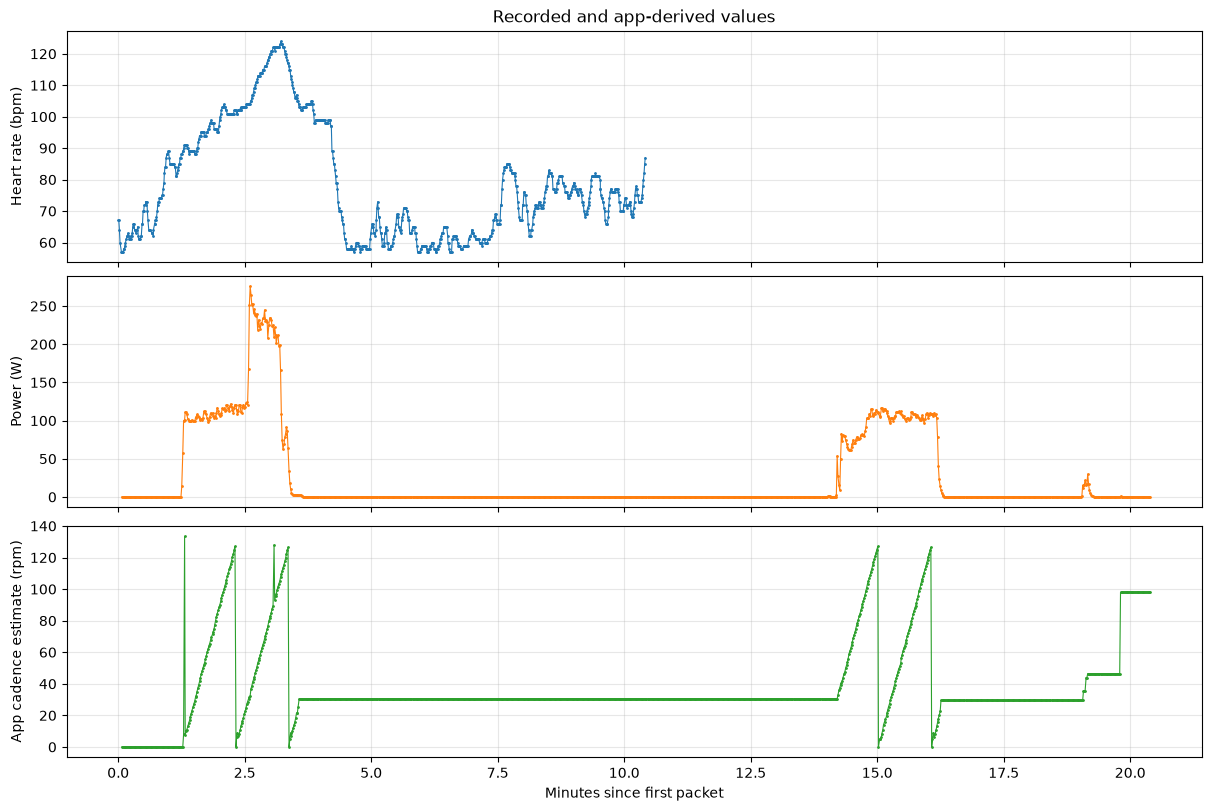

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
hr_notifications = heart[heart['delivery_method'] == 'notification']
axes[0].plot(hr_notifications['elapsed_s'] / 60, hr_notifications['heart_rate_bpm'],
             marker='.', markersize=2, linewidth=0.8)
axes[0].set(ylabel='Heart rate (bpm)', title='Recorded and app-derived values')
axes[1].plot(trainer['elapsed_s'] / 60, trainer['standard_power_w'],
             marker='.', markersize=2, linewidth=0.8, color='tab:orange')
axes[1].set(ylabel='Power (W)')
axes[2].plot(trainer['elapsed_s'] / 60, trainer['app_cadence_rpm'],
             marker='.', markersize=2, linewidth=0.8, color='tab:green')
axes[2].set(xlabel='Minutes since first packet', ylabel='App cadence estimate (rpm)')
for axis in axes:
    axis.grid(alpha=0.3)
plt.show()


## Do HR polls repeat notifications?

For each poll, compare the complete payload with the latest earlier HR notification within five seconds. A match means the poll returned the same characteristic value. It does not mean a new heart-rate measurement or another heartbeat occurred. A different payload may still contain the same bpm with new RR interval data.

In [34]:
notifications = heart[heart['delivery_method'] == 'notification'].dropna(subset=['timestamp'])
polls = heart[heart['delivery_method'] == 'poll'].dropna(subset=['timestamp'])
if notifications.empty or polls.empty:
    print('Both HR notification and poll rows are needed for this comparison.')
else:
    matched = pd.merge_asof(
        polls[['timestamp', 'raw_hex']].sort_values('timestamp'),
        notifications[['timestamp', 'raw_hex']].sort_values('timestamp'),
        on='timestamp', direction='backward', suffixes=('_poll', '_notification'),
        tolerance=pd.Timedelta(seconds=5),
    )
    comparable = matched['raw_hex_notification'].notna()
    duplicates = comparable & matched['raw_hex_poll'].eq(matched['raw_hex_notification'])
    print(f'Polls: {len(polls)}; within 5 s of prior notification: {comparable.sum()}; '
          f'identical payload: {duplicates.sum()} ({duplicates.sum() / comparable.sum():.1%} of comparable)'
          if comparable.any() else f'Polls: {len(polls)}; none within 5 s of prior notification')
    display(matched.assign(same_payload=duplicates).head(10))


Polls: 403; within 5 s of prior notification: 402; identical payload: 400 (99.5% of comparable)


,timestamp,raw_hex_poll,raw_hex_notification,same_payload
0,2026-10-09 17:37:19.096020300+00:00,0047,NaN,False
1,2026-10-09 17:37:20.534705100+00:00,10436004,10436004,True
2,2026-10-09 17:37:22.934706100+00:00,103CA004,103CA004,True
3,2026-10-09 17:37:24.375109200+00:00,10391604,10391604,True
4,2026-10-09 17:37:25.814677200+00:00,103AE703,103AE703,True
5,2026-10-09 17:37:27.254685+00:00,003B,003B,True
6,2026-10-09 17:37:28.695899900+00:00,103DB803,103DB803,True
7,2026-10-09 17:37:30.134697700+00:00,103E2304,103E2304,True
8,2026-10-09 17:37:32.295702900+00:00,103EF303,103EF303,True
9,2026-10-09 17:37:33.974717700+00:00,103DD803,103DD803,True


## Trainer packet structure and the speed question

The trainer rows use characteristic **2A63**, Cycling Power Measurement. Its first two bytes are flags. Bit 4 announces wheel revolution data, which can be used to calculate speed with a wheel circumference; bit 5 announces crank revolution data, which can be used to calculate cadence. Neither flag appears in these recordings. Their absence does not prove the trainer cannot provide these values elsewhere, but these packets have no standard wheel or crank data to decode.

The app tries an FTMS parser first even for these 2A63 packets. In a packet beginning `03006400`, bytes 2-3 contain **100 W**. The FTMS path reads bytes 1-2 as speed and reports **1.00 kph**. That speed is a parsing artifact, not a power-versus-gradient formula.

All observed trainer packets have 14 bytes although flags `0x0003` announce only the power and pedal-balance fields. The remaining bytes have no standard meaning under those flags. The table shows which positions change without assigning them units.

[Bluetooth SIG Cycling Power Service](https://www.bluetooth.com/specifications/specs/cycling-power-service/) describes the standard fields and flags.

In [35]:
if trainer.empty:
    print('No Cycling Power Measurement packets in this file.')
else:
    print('Flag values:', trainer['flags'].value_counts().to_dict())
    print('Packet lengths (bytes):', trainer['payload'].map(
        lambda p: len(p) if p is not None else None).value_counts().sort_index().to_dict())
    flag_values = trainer['payload'].map(
        lambda p: int.from_bytes(p[:2], 'little') if p and len(p) >= 2 else 0)
    print('Packets announcing wheel revolution data:', int((flag_values & 0x10 != 0).sum()))
    print('Packets announcing crank revolution data:', int((flag_values & 0x20 != 0).sum()))
    max_length = max((len(p) for p in trainer['payload'] if p is not None), default=0)
    byte_columns = pd.DataFrame({
        f'byte_{offset:02d}': trainer['payload'].map(
            lambda p, offset=offset: p[offset] if p and len(p) > offset else None).to_numpy()
        for offset in range(max_length)
    })
    byte_summary = pd.DataFrame({
        'unique_values': byte_columns.nunique(),
        'min': byte_columns.min(),
        'max': byte_columns.max(),
        'changed_from_previous': byte_columns.ne(byte_columns.shift()).sum() - 1,
    })
    display(byte_summary)
    display(trainer[['timestamp_utc', 'flags', 'standard_power_w', 'raw_hex']].head(12))


Flag values: {'0x0003': 1220}
Packet lengths (bytes): {14: 1220}
Packets announcing wheel revolution data: 0
Packets announcing crank revolution data: 0


,unique_values,min,max,changed_from_previous
byte_00,1,3,3,0
byte_01,1,0,0,0
byte_02,102,0,253,256
byte_03,2,0,1,2
byte_04,184,1,254,265
byte_05,4,0,3,3
byte_06,1,0,0,0
byte_07,1,0,0,0
byte_08,170,0,255,259
byte_09,189,0,254,265


,timestamp_utc,flags,standard_power_w,raw_hex
9,2026-10-09T17:37:23.4327587+00:00,0x0003,0,03000000BA000000000000000030
13,2026-10-09T17:37:24.6177643+00:00,0x0003,0,03000000BA000000000000000034
16,2026-10-09T17:37:25.5769291+00:00,0x0003,0,03000000BA000000000000000038
19,2026-10-09T17:37:26.7771841+00:00,0x0003,0,03000000BA00000000000000003C
22,2026-10-09T17:37:27.4976955+00:00,0x0003,0,03000000BA000000000000000040
25,2026-10-09T17:37:28.4569238+00:00,0x0003,0,03000000BA000000000000000044
28,2026-10-09T17:37:29.6569317+00:00,0x0003,0,03000000BA000000000000000048
32,2026-10-09T17:37:30.6169415+00:00,0x0003,0,03000000BA00000000000000004C
34,2026-10-09T17:37:31.5773631+00:00,0x0003,0,03000000BA000000000000000050
37,2026-10-09T17:37:32.5371435+00:00,0x0003,0,03000000BA000000000000000054


## Next recording

Connect the trainer and check its status in the app: `CSC: on` means CSC Measurement notifications started; `CSC: unavailable` means this connection did not provide them. Enable **Record raw device signals**, then ride a short sequence with known stopped, steady, and faster cadence phases. Inspect the new CSV above. If 2A5B rows are present, compare cadence calculated from crank events with the app's older byte-scan estimate. The old recordings contain only 2A63 trainer rows.

Garmin [lists public and private Tacx communication options](https://developer.garmin.com/tacx-trainer/overview/). The [pycycling project](https://github.com/zacharyedwardbull/pycycling) reports testing CSC with a Tacx NEO, but the exact services exposed by this trainer are only known after discovery. Garmin offers its private Tacx Trainer Service documentation by request; we have not shown that the extra 2A63 bytes use that private protocol.